### Notebook B: Examine radial and transverse scaling for multiple families

Here we read the scaling results obtained from multiple LFE families and analyse the results.

In [83]:
import numpy as np
import os
import matplotlib.pyplot as plt

import os,sys
sys.path.append(os.path.join(os.environ['PYFILES']))
import LFEAnalysis as lfeanalysis
lfeanalysis.reload_all(lfeanalysis)

<module 'LFEAnalysis.read_catalogues' from '/Users/jessicahawthorne/PYFILES/LFEAnalysis/read_catalogues.py'>
<module 'LFEAnalysis._lfe_initiation' from '/Users/jessicahawthorne/PYFILES/LFEAnalysis/_lfe_initiation.py'>
<module 'LFEAnalysis._seismic_data_management' from '/Users/jessicahawthorne/PYFILES/LFEAnalysis/_seismic_data_management.py'>
<module 'LFEAnalysis._lfe_detections' from '/Users/jessicahawthorne/PYFILES/LFEAnalysis/_lfe_detections.py'>
<module 'LFEAnalysis._lfe_arrivals' from '/Users/jessicahawthorne/PYFILES/LFEAnalysis/_lfe_arrivals.py'>
<module 'LFEAnalysis._lfe_download_data' from '/Users/jessicahawthorne/PYFILES/LFEAnalysis/_lfe_download_data.py'>
<module 'LFEAnalysis._lfe_stacking' from '/Users/jessicahawthorne/PYFILES/LFEAnalysis/_lfe_stacking.py'>
<module 'LFEAnalysis._lfe_grouping' from '/Users/jessicahawthorne/PYFILES/LFEAnalysis/_lfe_grouping.py'>
<module 'LFEAnalysis._lfe_xc' from '/Users/jessicahawthorne/PYFILES/LFEAnalysis/_lfe_xc.py'>
<module 'LFEAnalysis._l

### 1. Pick the families, region, and catalog to consider

In [84]:
# pick some families to analyse
# which families
fnums=np.array([74,246,66,23,144,70,65,156,61,23,55,3,7,49,142,31,256,12,70,53,22,30,52,62,191,1],dtype=int)
#fnums=[74,156]
fnums=np.unique(fnums)
print('Families to analyse:\n',fnums)

# note the region and catalog
region='Cascadia'
catalog='Bostock'

# and the data directory in case you need to change it
data_directory=None

Families to analyse:
 [  1   3   7  12  22  23  30  31  49  52  53  55  61  62  65  66  70  74
 142 144 156 191 246 256]


### 2. Read in the results

In [85]:
# initialise an analysis object for an arbitrary family
lf=lfeanalysis.lfeanalyse(fnum=fnums[0],region=region,catalog=catalog,
                          data_directory=data_directory)

# and collect the results information from multiple families
lf.collect_results(fnums=fnums)


Family 1
Family 3
Family 7
Family 12
Family 22
Family 23
Family 30
Family 31
Family 49
Family 52
Family 53
Family 55
Family 61
Family 62
Family 65
Family 66
Family 70
Family 74
Family 142
Family 144
Family 156
Family 191
Family 246
Family 256


The function collect_results read results information from each of the saved objects---one for each family.  These objects have scaling parameters obtained for each station.  The collect_results function just renames the station, appending the family name to the station name.  Then it collects all the stations together, so that it looks like we have one collective LFE family with a bunch of stations.  This way we can use the same object and all the same functions that we'd use for individual family analysis.

In [86]:
print('The family numbers are saved in lf.fnums :\n',lf.fnums)

print('\nThe family locations are saved in lf.flocs, with their mean in lf.floc:\n:',lf.floc)

The family numbers are saved in lf.fnums :
 [  1   3   7  12  22  23  30  31  49  52  53  55  61  62  65  66  70  74
 142 144 156 191 246 256]

The family locations are saved in lf.flocs, with their mean in lf.floc:
: [-123.72622083   48.46850833   36.22583333]


In [87]:
print('The collected scaling parameters are in lf.scalings and lf.scalingsc as before, but with new station names.')
ky=list(lf.scalingsc.keys())[0]
print('For instance, the {:s} group includes data from stations\n'.format(ky),list(lf.scalingsc[ky].keys()))

The collected scaling parameters are in lf.scalings and lf.scalingsc as before, but with new station names.
For instance, the early group includes data from stations
 ['1-B926', '1-B927', '1-LZB', '1-MGB', '1-MGCB', '1-TWBB', '1-YOUB', '3-B007', '3-B011', '3-B926', '3-KHVB', '3-LZB', '3-MGB', '3-MGCB', '3-NLLB', '3-PGC', '3-SHB', '3-SHDB', '3-SNB', '3-YOUB', '7-B926', '7-LZB', '7-MGCB', '7-NLLB', '7-PFB', '7-PGC', '7-SHDB', '7-YOUB', '12-B011', '12-KHVB', '12-MGCB', '12-NLLB', '12-PGC', '12-SHDB', '22-B011', '22-B926', '22-KHVB', '22-LZB', '22-MGCB', '22-PGC', '22-SHDB', '22-YOUB', '23-B011', '23-B926', '23-KHVB', '23-LZB', '23-MGCB', '23-PGC', '23-SHDB', '23-SNB', '23-TWBB', '23-YOUB', '30-B011', '30-B926', '30-LZB', '30-MGCB', '30-NLLB', '30-PGC', '30-SNB', '30-YOUB', '31-B011', '31-B926', '31-KHVB', '31-LZB', '31-MGCB', '31-NLLB', '31-PGC', '31-SHDB', '31-SNB', '31-YOUB', '49-B011', '49-B926', '49-LZB', '49-MGB', '49-MGCB', '49-NLLB', '49-PFB', '49-PGC', '49-SHDB', '49-SNB', '49-YOU

There is no perfect way to consider the station locations relative to the LFEs, as different LFEs are at different depths and will have different phases and arrival times, even for stations at the same distances and azimuths.   However, several approaches to the normalisation are saved for potential analysis.  These include
- statdst: the distances from the LFEs to the stations, in km
- stataz: the azimuths from the LFEs to the stations
- statxy: the x-y distance from the LFEs to the stations, projected into a flat plane
- statxym: a modified x-y distance from the LFEs to the stations, projected into a flat plane.  This value maps the station locations to match the takeoff angles of an upgoing s wave, assuming an LFE depth of lf.refdepth
- arrival_times : the arrival times of the seismic waves, in seconds
- phases : the phases of the arriving seismic waves ('s' and/or 'S')
- takeoff_angles : the takeoff angles (degrees from down) of the seismic waves

In [88]:
print('The modified distances from the LFEs to the stations are in lf.statxym')
ky=list(lf.statxym.keys())[0]
fnum,stn=ky.split('-')
print('For instance, the modified distance for station {:s} from family {:s} is '.format(stn,fnum),lf.statxym[ky])

The modified distances from the LFEs to the stations are in lf.statxym
For instance, the modified distance for station BPCB from family 1 is  [13.6262987 50.2478753]


In [89]:
print('lf.statxym only makes sense for the upgoing s wave')
print('But the takeoff angles for all phases are in lf.takeoff_angles')
print('For instance, the takeoff angles for station {:s} from family {:s} are '.format(stn,fnum),lf.takeoff_angles[ky])
print('The phases for station {:s} from family {:s} are '.format(stn,fnum),lf.phases[ky])
print('These phases are expected after times',lf.arrival_times[ky])

lf.statxym only makes sense for the upgoing s wave
But the takeoff angles for all phases are in lf.takeoff_angles
For instance, the takeoff angles for station BPCB from family 1 are  [113.22635383  56.99430811  61.93096797]
The phases for station BPCB from family 1 are  ['s' 'S' 'S']
These phases are expected after times [18.92687545 19.41399201 19.46789378]


### 3. Calculate the radiation coefficients and their ratios

In [125]:
# first calculate the radiation coefficients for shear and opening motion on the fault
lf.calc_radiation_coefficients(strike=315,dip=20,rake=90)

# then calculate the ratios of the opening to the shear radiation coefficients
lf.calc_radcoeff_ratios(phase='weighted')

### 4. Examine the scaling parameters as a function of modified distance

As before, we can plot the change in the radial and/or transverse scaling coefficient as a function of "station location".

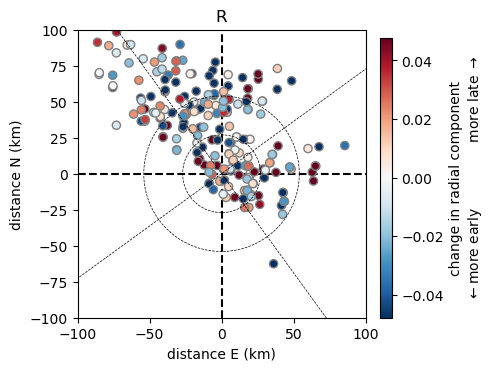

In [94]:
lf.plot_scaling_by_location(cplot=['R'],grps=['late - early'],width=200)

Encouragingly, we now have lots of values.  However, the plotted values mostly look like a scatterplot.  There are no obvious patterns, likely because we're mostly plotting noise.

### 4. Examine the mean and medians in various groups of station-family pairs

Given the uncertainty, it makes more sense to average over groups of values.

In [97]:
lf.scalingsc['early'].keys()

dict_keys(['1-B926', '1-B927', '1-LZB', '1-MGB', '1-MGCB', '1-TWBB', '1-YOUB', '3-B007', '3-B011', '3-B926', '3-KHVB', '3-LZB', '3-MGB', '3-MGCB', '3-NLLB', '3-PGC', '3-SHB', '3-SHDB', '3-SNB', '3-YOUB', '7-B926', '7-LZB', '7-MGCB', '7-NLLB', '7-PFB', '7-PGC', '7-SHDB', '7-YOUB', '12-B011', '12-KHVB', '12-MGCB', '12-NLLB', '12-PGC', '12-SHDB', '22-B011', '22-B926', '22-KHVB', '22-LZB', '22-MGCB', '22-PGC', '22-SHDB', '22-YOUB', '23-B011', '23-B926', '23-KHVB', '23-LZB', '23-MGCB', '23-PGC', '23-SHDB', '23-SNB', '23-TWBB', '23-YOUB', '30-B011', '30-B926', '30-LZB', '30-MGCB', '30-NLLB', '30-PGC', '30-SNB', '30-YOUB', '31-B011', '31-B926', '31-KHVB', '31-LZB', '31-MGCB', '31-NLLB', '31-PGC', '31-SHDB', '31-SNB', '31-YOUB', '49-B011', '49-B926', '49-LZB', '49-MGB', '49-MGCB', '49-NLLB', '49-PFB', '49-PGC', '49-SHDB', '49-SNB', '49-YOUB', '52-B011', '52-B926', '52-LZB', '52-MGCB', '52-PGC', '52-SNB', '52-YOUB', '53-B011', '53-B926', '53-KHVB', '53-LZB', '53-MGCB', '53-PGC', '53-SHDB', '53-

['SV ratio: 0.0 - 1.5, SH ratio: -1.5 - -0.5', 'SV ratio: 1.5 - 3.0, SH ratio: -1.5 - -0.5', 'SV ratio: 3.0 - 10.0, SH ratio: -1.5 - -0.5']


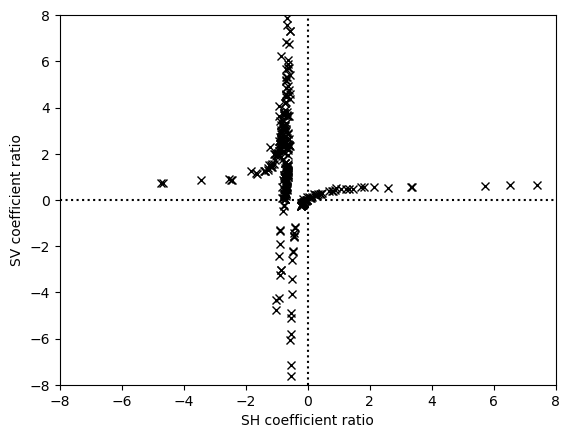

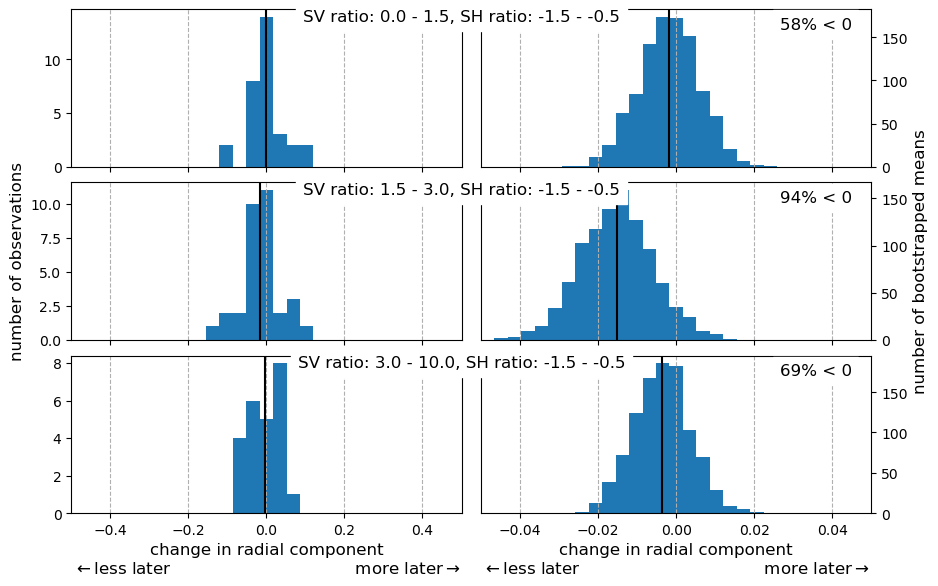

In [141]:
lfeanalysis.reload_all(lfeanalysis)
lf=lfeanalysis.lfeanalyse(lfi=lf)

lf.plot_radcoeff_ratios()
statlist,binlabel=lf.bin_stations_by_takeoff()
statlist,binlabel=lf.bin_stations_by_radcoeff(svlms=[0,1.5,3,10],shlms=[-1.5,-0.5])
print(binlabel)

#print(statlist,binlabel)
lf.plot_binned_coefficients(avetype='mean',statlist=statlist,binlabel=binlabel)

In [111]:
lf.radcoeff_ratios.keys()

dict_keys(['P', 'SH', 'SV'])